## Fit model


In [1]:
import pickle
import math
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from tqdm.autonotebook import tqdm
from IPython.display import Audio, display
import noisereduce as nr

rng = np.random.default_rng(0)

/tmp/ipykernel_1034091/3186357411.py:15: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [2]:
bout_df = pd.read_pickle('bird_A_songs.pkl')
syl_df = pd.read_pickle('bird_A_syls.pkl')

In [3]:
songs_wav = bout_df.waveform.values
waveform_lengths = [x.shape[-1] for x in songs_wav]

In [4]:
# build voicing masks per song
win_ms, hop_ms = 16, 4

def get_stft_frame_count(y, fs, win_length, hop_length, n_fft):
    _, t, _ = signal.stft(y, fs=fs, window='hann', nperseg=win_length,
                          noverlap=win_length-hop_length, nfft=n_fft,
                          return_onesided=True, boundary='zeros', padded=True)
    return len(t)

masks_native, masks_hop, stft_params = [], [], []
for bout_idx, wav in enumerate(songs_wav):
    fs = bout_df.iloc[bout_idx].sample_rate
    win_length = int(win_ms / 1000 * fs)
    hop_length = int(hop_ms / 1000 * fs)
    n_fft = 2 ** math.ceil(math.log2(win_length))
    stft_params.append((fs, win_length, hop_length, n_fft))
    syl_rows = syl_df[syl_df['bout_index'] == bout_idx]
    n = len(wav)
    T = get_stft_frame_count(wav, fs, win_length, hop_length, n_fft)
    mn = np.zeros(n, dtype=bool)
    mh = np.zeros(T, dtype=bool)
    pad_frames = 0
    for _, syl in syl_rows.iterrows():
        start_n = max(int(syl['on_sample']), 0)
        end_n   = min(int(syl['off_sample']), n)
        mn[start_n:end_n] = True
        start_h = max((syl['on_sample'] // hop_length) - pad_frames, 0)
        end_h   = min((syl['off_sample'] // hop_length) + pad_frames*2, T)
        mh[start_h:end_h] = True
    masks_native.append(mn)
    masks_hop.append(mh)

#### Make sure the pitch fit looks good

In [5]:
from vibe import get_pitch, estimate_amplitude, song_to_parameters, synthesize_song, fitter

In [18]:
song_idx = 2
y = songs_wav[song_idx]
vmask_native = masks_native[song_idx]
vmask = masks_hop[song_idx]
fs_audio, win_length, hop_length, n_fft = stft_params[song_idx]

In [19]:
pitch_kwargs = {
    'f0_min': 300.0,
    'f0_max': 4000.0,
    'freq_boost_exp': 5.0,    # increase to favor low freqs more (default: 1.0)
    'harmonic_bonus': 5.0,    # increase if harmonics are strong (default: 5.0)
    'min_prominence_db': 1.0  # lower if peaks are weak (default: 5.0)
}

y_denoised = nr.reduce_noise(y=y, sr=fs_audio, prop_decrease=1.0)
pitch, mag_db, freqs, times = get_pitch(y_denoised, vmask, fs_audio, hop_length, win_length, n_fft, **pitch_kwargs)
_, mag_db, freqs, times = get_pitch(y, vmask, fs_audio, hop_length, win_length, n_fft, **pitch_kwargs)

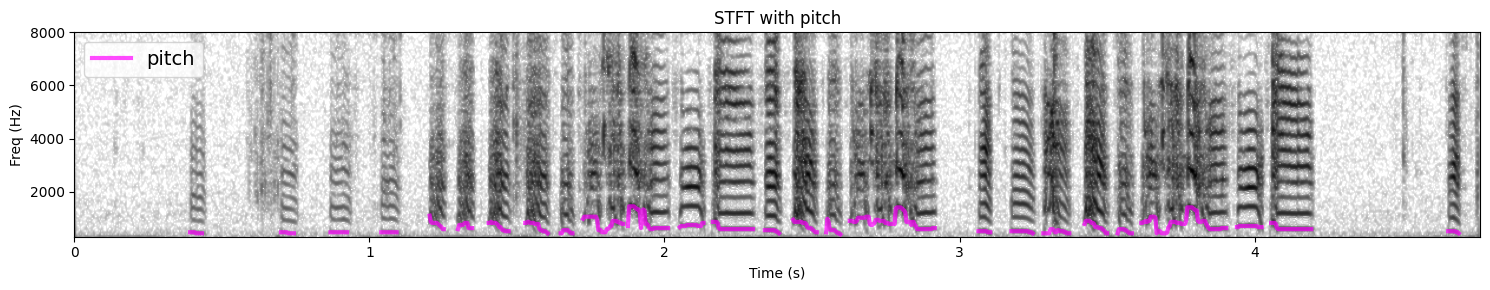

In [20]:
fig, ax = plt.subplots(figsize=(15, 3))

img = ax.imshow(mag_db, aspect='auto', origin='lower', cmap='gray_r',
                extent=[times[0], times[-1], freqs[0], freqs[-1]],
                vmin=np.percentile(mag_db, 10), vmax=0.98*np.max(mag_db))

plt.ylim(300, 8000)
ax.set_ylabel("Freq (Hz)")
ax.set_xlabel("Time (s)")
ax.set_title('STFT with pitch')

ax.plot(times, pitch, 'magenta', linewidth=3, alpha=0.7, label='pitch')
ax.legend(fontsize=14, loc='upper left')
plt.tight_layout()
plt.show()

VIBE requires a pitch estimate at every voiced frame, even those without evident harmonicity.

### Then fit model for all songs

In [23]:
use_noise_reduce = True

alphas, betas, fit_results, rec_wavs, failed = {}, {}, {}, {}, {}

for song_idx in tqdm(range(len(songs_wav)), desc="VIBE fit"):
    if song_idx in alphas:
        continue
    try:
        y = songs_wav[song_idx]
        vmask = masks_hop[song_idx]
        fs_audio, win_length, hop_length, n_fft = stft_params[song_idx]

        if use_noise_reduce:
            y_denoised = nr.reduce_noise(y=y, sr=fs_audio, prop_decrease=1.0)
            alpha, beta, fit_result = song_to_parameters(
                y_denoised, fs_audio, vmask, hop_length, win_length, n_fft, pitch_kwargs)
        else:
            alpha, beta, fit_result = song_to_parameters(
                y, fs_audio, vmask, hop_length, win_length, n_fft, pitch_kwargs)
        rec_wav = synthesize_song(alpha, beta, fs_audio, len(y))

        alphas[song_idx] = alpha
        betas[song_idx]  = beta
        fit_results[song_idx] = fit_result
        rec_wavs[song_idx] = rec_wav
    except Exception as e:
        failed[song_idx] = repr(e)
        print(f"  song {song_idx} failed: {e}")

    with open('vibe_fits_checkpoint.pkl', 'wb') as f:
        pickle.dump({'alphas': alphas, 'betas': betas, 'fit_results': 
                     fit_results, 'rec_wavs': rec_wavs, 'failed': failed}, f)

print(f"\ndone: {len(alphas)}/{len(songs_wav)} fit, {len(failed)} failed")
if failed:
    print("failed indices:", list(failed.keys()))

VIBE fit:   0%|          | 0/50 [00:00<?, ?it/s]

Extracting isopitch contours...


  0%|          | 0/1126 [00:00<?, ?it/s]

Computing percentile-based initialization...
Optimizing with adaptive batching (batch_size=30)...
  Batch 1: batch best = 0.9111, overall best = 0.9111
  Batch 2: batch best = 0.9088, overall best = 0.9111
  Batch 3: batch best = 0.9152, overall best = 0.9152
  Batch 4: batch best = 0.9071, overall best = 0.9152
  Batch 5: batch best = 0.9136, overall best = 0.9152
  Batch 6: batch best = 0.9060, overall best = 0.9152
  Converged! No improvement for 3 batches
Optimization complete!
Final correlation: 0.9152
Smoothness: 57.5337
Total trials: 180
Parallel VT CPU: 16 windows @ 128 frames | workers=16 | 30.581s | len=325600
Extracting isopitch contours...


  0%|          | 0/404 [00:00<?, ?it/s]

...

Computing percentile-based initialization...
Optimizing with adaptive batching (batch_size=30)...
  Batch 1: batch best = 0.9814, overall best = 0.9814
  Batch 2: batch best = 0.9907, overall best = 0.9907
  Batch 3: batch best = 0.9917, overall best = 0.9917
  Batch 4: batch best = 0.9903, overall best = 0.9917
  Batch 5: batch best = 0.9929, overall best = 0.9929
  Batch 6: batch best = 0.9953, overall best = 0.9953
  Batch 7: batch best = 0.9883, overall best = 0.9953
  Batch 8: batch best = 0.9938, overall best = 0.9953
  Batch 9: batch best = 0.9923, overall best = 0.9953
  Converged! No improvement for 3 batches
Optimization complete!
Final correlation: 0.9953
Smoothness: 16.2830
Total trials: 270
Parallel VT CPU: 8 windows @ 128 frames | workers=8 | 15.692s | len=145440
Extracting isopitch contours...


  0%|          | 0/302 [00:00<?, ?it/s]

Computing percentile-based initialization...
Optimizing with adaptive batching (batch_size=30)...
  Batch 1: batch best = 0.9846, overall best = 0.9846
  Batch 2: batch best = 0.9827, overall best = 0.9846
  Batch 3: batch best = 0.9804, overall best = 0.9846
  Batch 4: batch best = 0.9826, overall best = 0.9846
  Converged! No improvement for 3 batches
Optimization complete!
Final correlation: 0.9846
Smoothness: 18.2871
Total trials: 120
Parallel VT CPU: 7 windows @ 128 frames | workers=7 | 15.960s | len=130240
Extracting isopitch contours...


  0%|          | 0/327 [00:00<?, ?it/s]

Computing percentile-based initialization...
Optimizing with adaptive batching (batch_size=30)...
  Batch 1: batch best = 0.9940, overall best = 0.9940
  Batch 2: batch best = 0.9927, overall best = 0.9940
  Batch 3: batch best = 0.9913, overall best = 0.9940
  Batch 4: batch best = 0.9932, overall best = 0.9940
  Converged! No improvement for 3 batches
Optimization complete!
Final correlation: 0.9940
Smoothness: 13.6199
Total trials: 120
Parallel VT CPU: 7 windows @ 128 frames | workers=7 | 15.746s | len=142080

done: 50/50 fit, 0 failed


In [24]:
corrs = np.array([fr['correlation'] for fr in fit_results.values()])
corrs = corrs[np.isfinite(corrs)]

print(f"amplitude fit r: {corrs.mean():.3f} ± {corrs.std(ddof=1):.3f} "
      f"(mean ± SD, n={len(corrs)} songs)  range {corrs.min():.3f}–{corrs.max():.3f}")

amplitude fit r: 0.975 ± 0.022 (mean ± SD, n=50 songs)  range 0.915–0.997


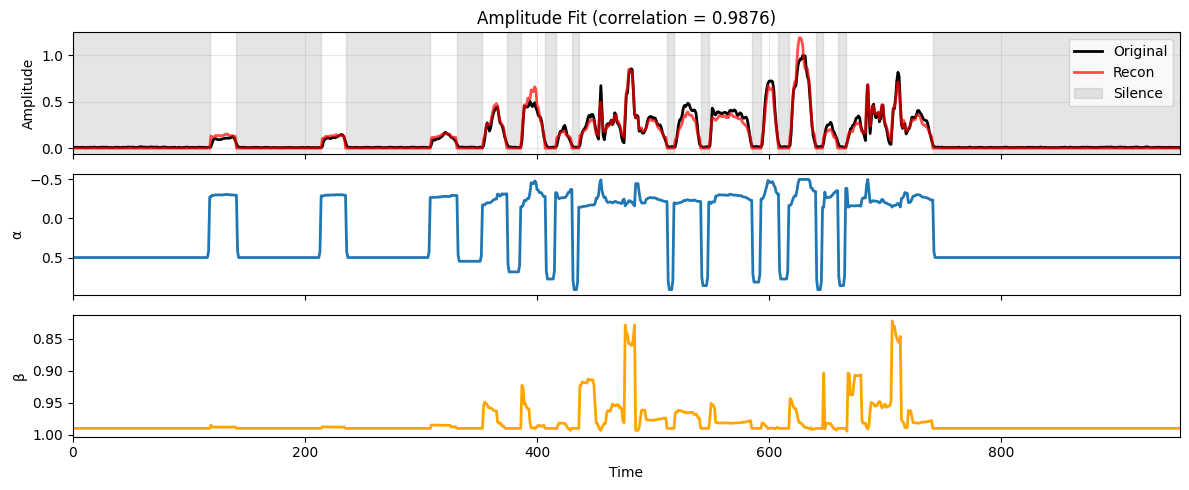

In [36]:
song_idx = 3
fit_result = fit_results[song_idx]
T = len(fit_result['model_amplitude'])
fs_audio, win_length, hop_length, n_fft = stft_params[song_idx]

vmask = np.asarray(masks_hop[song_idx])
y = songs_wav[song_idx]
y_denoised = nr.reduce_noise(y=y, sr=fs_audio, prop_decrease=1.0)
song_pitch, *_ = get_pitch(y_denoised, vmask, fs_audio, hop_length, win_length, n_fft, **pitch_kwargs)
song_amplitude = estimate_amplitude(y.astype(float), fs_audio, win_length, hop_length, n_fft)
song_amplitude = np.asarray(song_amplitude / song_amplitude.max())

# pad/trim every display array to exactly T so plot_fit's internal indexing matches model_amplitude
def fit_to_T(a, T):
    a = np.asarray(a)
    if len(a) >= T: return a[:T]
    return np.concatenate([a, np.full(T - len(a), a[-1] if len(a) else 0)])

fig = fitter.plot_fit(
    fit_to_T(song_pitch, T),
    fit_to_T(song_amplitude, T),
    fit_result,
    fit_to_T(vmask, T).astype(bool),
    time=np.arange(T),
)
plt.show()

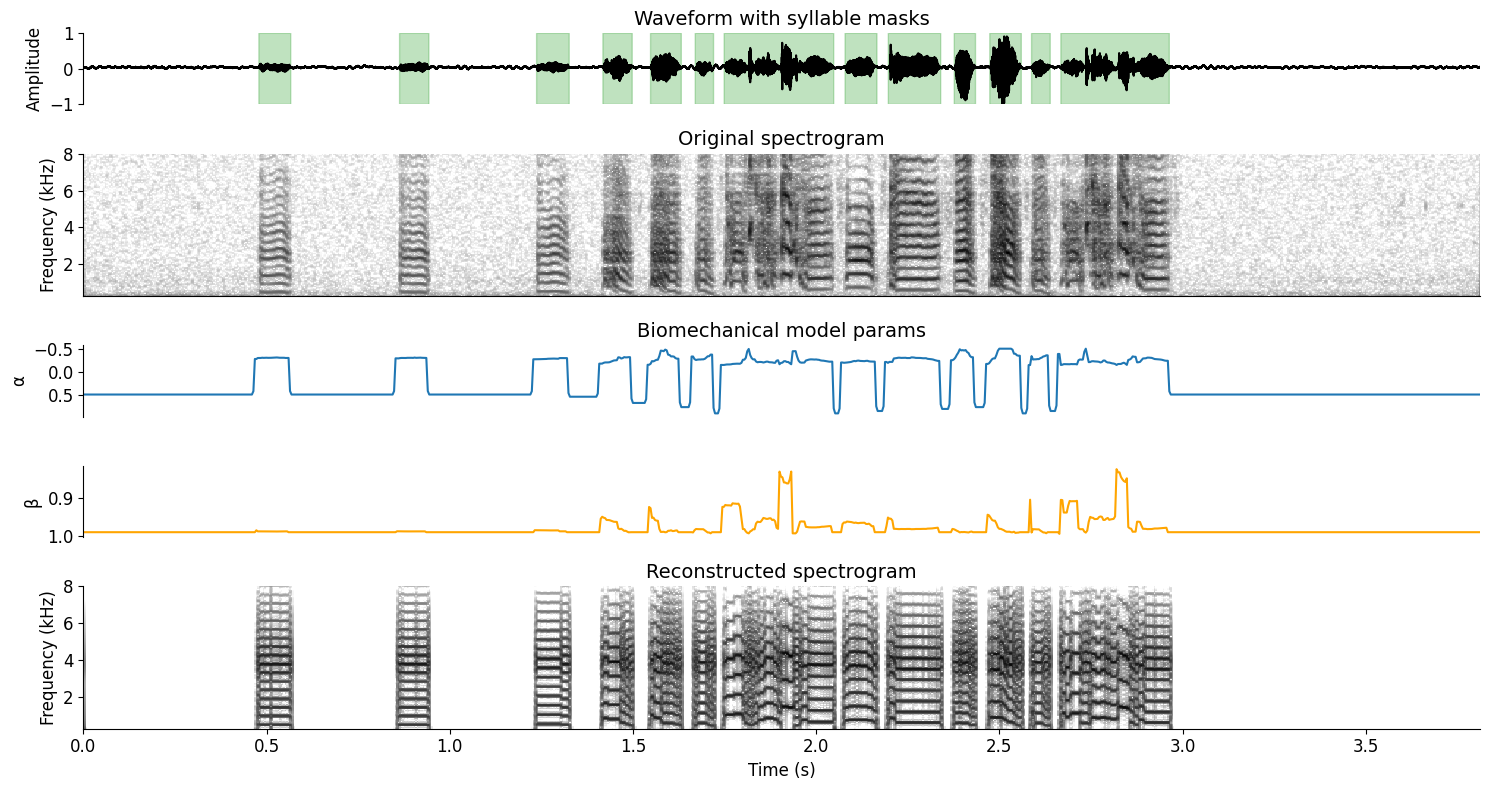

In [37]:
fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(
    5, 1, figsize=(15, 8), sharex=True, gridspec_kw={'height_ratios': [1, 2, 1, 1, 2]}
)

alpha   = alphas[song_idx]
beta    = betas[song_idx]
rec_wav = rec_wavs[song_idx]

# Waveform
time_wav = np.arange(len(y)) / fs_audio
ax1.plot(time_wav, y / np.abs(y).max(), 'k')
syl_rows = syl_df[syl_df['bout_index'] == song_idx]
T = get_stft_frame_count(y, fs_audio, win_length, hop_length, n_fft)
m = np.zeros(len(y), dtype=bool)
for _, syl in syl_rows.iterrows():
    start_n = max(int(syl['on_sample']), 0)
    end_n   = min(int(syl['off_sample']), len(y))
    m[start_n:end_n] = True
ax1.fill_between(time_wav, -1, 1, where=m, alpha=0.3, color='C2')
ax1.set_title('Waveform with syllable masks')
ax1.set_ylabel('Amplitude')
ax1.set_ylim([-1, 1])

# Spectrogram
D = librosa.stft(y.astype(float), n_fft=n_fft, hop_length=hop_length, win_length=win_length)
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
time_spec = librosa.frames_to_time(np.arange(S_db.shape[1]), sr=fs_audio, hop_length=hop_length)
freqs = librosa.fft_frequencies(sr=fs_audio, n_fft=n_fft)
im = ax2.pcolormesh(time_spec, freqs, S_db, shading='auto', cmap='gray_r',
                    vmin=np.percentile(S_db, 15), vmax=0.97*np.max(S_db), rasterized=True)
ax2.set_title('Original spectrogram')
ax2.set_ylabel('Frequency (kHz)')
ax2.set_xlim([time_spec[0], time_spec[-1]])
ax2.set_ylim([250, 8000])
ax2.set_yticks([2000, 4000, 6000, 8000])
ax2.set_yticklabels(['2', '4', '6', '8'])

# alpha
ax3.plot(time_spec, alpha[-len(time_spec):])
ax3.set_ylabel('α')
ax3.invert_yaxis()
ax3.set_title('Biomechanical model params')

# beta
ax4.plot(time_spec, beta[-len(time_spec):], color='orange')
ax4.set_ylabel('β')
ax4.invert_yaxis()

# Spectrogram
D = librosa.stft(rec_wav.astype(float), n_fft=n_fft, hop_length=hop_length, win_length=win_length)
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
time_spec = librosa.frames_to_time(np.arange(S_db.shape[1]), sr=fs_audio, hop_length=hop_length)
freqs = librosa.fft_frequencies(sr=fs_audio, n_fft=n_fft)
im = ax5.pcolormesh(time_spec, freqs, S_db, shading='auto', cmap='gray_r', vmin=-55, vmax=0, rasterized=True)
ax5.set_title('Reconstructed spectrogram')
ax5.set_ylabel('Frequency (kHz)')
ax5.set_ylim([250, 8000])
ax5.set_yticks([2000, 4000, 6000, 8000])
ax5.set_yticklabels(['2', '4', '6', '8'])
ax5.set_xlabel('Time (s)')

for ax in fig.axes:
    ax.title.set_fontsize(14)
    ax.xaxis.label.set_fontsize(12)
    ax.yaxis.label.set_fontsize(12)
    for label in ax.get_xticklabels():
        label.set_fontsize(12)
    for label in ax.get_yticklabels():
        label.set_fontsize(12)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if ax != ax2 and ax != ax5:
        ax.spines['bottom'].set_visible(False)
    if ax != ax5:
        ax.tick_params(axis='x', labelbottom=False, bottom=False)

plt.tight_layout()
plt.show()

In [38]:
print("original")
display(Audio(y, rate=fs_audio))
print("resynthesized")
display(Audio(rec_wav, rate=fs_audio))

original


resynthesized
